# CMB Fisher Forecast: candl + clipy Planck + ACT DR6 lensing (nuLCDM)

This notebook forecasts CMB constraints from the Hessian approximation at the fiducial point,
using `candl` for all likelihood interfaces and `clipy` through the `candl` wrapper for the Planck terms.
The Fisher approximation is
$$F_{ij} \approx -\partial_i \partial_j \log \mathcal{L}(\theta_\mathrm{fid}).$$
The Hessian is evaluated at the common Planck 2018 `TT,TE,EE+lowE+lensing+BAO` fiducial used by the other Fisher notebooks. For LCDM, the neutrino mass sum is fixed to the minimal value; for nuLCDM, the same fiducial point is used with `Σmν=0.06 eV` varied.

In [1]:
from pathlib import Path
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-jaxptpolypol')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import candl_data

from jaxptpolypol.cmb import (
    CandlParameterLayout,
    get_candl_default_parameters,
    get_candl_parameter_names,
    load_candl_likelihood,
    make_candl_loglike_fn,
    make_candl_pars_to_theory_specs_fn,
    make_joint_loglike_fn,
)
from jaxptpolypol.inference import fisher_diagnostics, format_fisher_diagnostics
from jaxptpolypol.params import CosmoParams


In [2]:
PLANCK_ROOT = Path('/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0')
PLANCK_HIGHL = PLANCK_ROOT / 'hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik'
PLANCK_LOWL_TT = PLANCK_ROOT / 'low_l/commander/commander_dx12_v3_2_29.clik'
PLANCK_LOWL_EE = PLANCK_ROOT / 'low_l/simall/simall_100x143_offlike5_EE_Aplanck_B.clik'
PLANCK_LENSING = PLANCK_ROOT / 'lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing'
ACT_DR6_LENS = candl_data.ACT_DR6_Lens_only

EMULATOR_DIR = Path('/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks')
EMULATOR_FILENAMES = {
    'TT': str(EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_tt.npz'),
    'TE': str(EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_te.npz'),
    'EE': str(EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_ee.npz'),
    'pp': str(EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_pp.npz'),
}

# Planck 2018 TT,TE,EE+lowE+lensing+BAO fiducial; minimal Σmν = 0.06 eV.
COSMO_KEYS = ('H0', 'ombh2', 'omch2', 'logA', 'ns', 'tau', 'mnu')
FIDUCIAL_COSMO = {'H0': 67.66, 'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'tau': 0.0561, 'mnu': 0.06}


MARGINALIZE_CMB_NUISANCE = True
INCLUDE_INTERNAL_PRIORS = True
COMPARE_NUISANCE_MODES = False
CONTOUR_PAIR = ('mnu', 'tau')

PLANCK_TERM_KEYS = ['planck_highl', 'planck_lowl_tt', 'planck_lowl_ee', 'planck_lensing']
ALL_TERM_KEYS = PLANCK_TERM_KEYS + ['act_dr6_lensing']
TERM_LABELS = {
    'planck_highl': 'Planck high-$\ell$ TTTEEE',
    'planck_lowl_tt': 'Planck low-$\ell$ TT',
    'planck_lowl_ee': 'Planck low-$\ell$ EE',
    'planck_lensing': 'Planck lensing',
    'act_dr6_lensing': 'ACT DR6 lensing',
}
PARAM_LABELS = {
    'H0': r'$H_0$',
    'ombh2': r'$\omega_b$',
    'omch2': r'$\omega_c$',
    'logA': r'$\log(10^{10}A_s)$',
    'ns': r'$n_s$',
    'tau': r'$\tau$',
    'mnu': r'$\Sigma m_\nu$',
}

print('Planck root:', PLANCK_ROOT)
print('Planck lensing file:', PLANCK_LENSING)
print('ACT DR6 lensing YAML:', ACT_DR6_LENS)
print('Emulator files:')
for spec, path in EMULATOR_FILENAMES.items():
    print(f'  {spec}: {path}')
print('Mode:', 'marginalize_cmb_nuisance' if MARGINALIZE_CMB_NUISANCE else 'cosmology_only')
print('Include internal priors:', INCLUDE_INTERNAL_PRIORS)


Planck root: /Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0
Planck lensing file: /Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing
ACT DR6 lensing YAML: /Users/nguyenmn/candl/candl_data/candl_data/ACT_DR6_Lens_v1/ACT_DR6_KK_lens_only.yaml
Emulator files:
  TT: /Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Cl_tt.npz
  TE: /Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Cl_te.npz
  EE: /Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Cl_ee.npz
  pp: /Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Cl_pp.npz
Mode: marginalize_cmb_nuisance
Include internal priors: True


## Low-$\ell$ EE (simall) note

`planck_lowl_ee`/simall is now differentiable in clipy (cubic-spline likelihood), so each CMB Hessian Fisher carries the real low-$\ell$ EE information on `tau` directly. **No Gaussian `tau` prior is added** — the lowE optical-depth constraint comes from the likelihood's own curvature.


In [3]:
def scalar_value(value):
    return float(np.asarray(value).reshape(()))


def ordered_union(name_lists):
    ordered = []
    seen = set()
    for names in name_lists:
        for name in names:
            if name not in seen:
                seen.add(name)
                ordered.append(name)
    return tuple(ordered)


def load_likelihood_terms(include_internal_priors=True):
    clipy_args = {'all_priors': True} if include_internal_priors else {}
    return {
        'planck_highl': load_candl_likelihood(
            str(PLANCK_HIGHL),
            wrapper='clipy',
            additional_args=clipy_args,
        ),
        'planck_lowl_tt': load_candl_likelihood(
            str(PLANCK_LOWL_TT),
            wrapper='clipy',
            additional_args=clipy_args,
        ),
        'planck_lowl_ee': load_candl_likelihood(
            str(PLANCK_LOWL_EE),
            wrapper='clipy',
            additional_args=clipy_args,
        ),
        'planck_lensing': load_candl_likelihood(
            str(PLANCK_LENSING),
            wrapper='clipy',
            additional_args=clipy_args,
        ),
        'act_dr6_lensing': load_candl_likelihood(
            ACT_DR6_LENS,
            lensing=True,
            feedback=False,
            clear_internal_priors=not include_internal_priors,
        ),
    }


def collect_cmb_nuisance_defaults(likelihoods):
    nuisance_names_by_term = {}
    nuisance_defaults = {}
    for term_name, like in likelihoods.items():
        names = get_candl_parameter_names(
            like,
            cosmo_keys=COSMO_KEYS,
            include_prior_params=True,
        )
        nuisance_names_by_term[term_name] = names
        for key, value in get_candl_default_parameters(like).items():
            nuisance_defaults.setdefault(key, scalar_value(value))

    nuisance_names = ordered_union(nuisance_names_by_term.values())
    missing_defaults = [name for name in nuisance_names if name not in nuisance_defaults]
    if missing_defaults:
        raise ValueError(
            'Missing default values for CMB nuisance parameters: '
            + ', '.join(missing_defaults)
        )
    return nuisance_names, nuisance_defaults, nuisance_names_by_term


def build_layout_and_fiducial(nuisance_names, nuisance_defaults, marginalize_cmb_nuisance):
    sampled_nuisance = tuple(nuisance_names if marginalize_cmb_nuisance else ())
    layout = CandlParameterLayout(
        cosmo_keys=tuple(COSMO_KEYS),
        cosmo_sizes=tuple(1 for _ in COSMO_KEYS),
        cmb_nuisance_names=sampled_nuisance,
    )
    theta_fid = layout.pack(
        CosmoParams(FIDUCIAL_COSMO),
        {name: nuisance_defaults[name] for name in sampled_nuisance},
    )
    fixed_cmb_params = {
        name: nuisance_defaults[name]
        for name in nuisance_names
        if name not in set(sampled_nuisance)
    }
    return layout, theta_fid, fixed_cmb_params


def build_term_loglikes(likelihoods, layout, fixed_cmb_params, pars_to_theory_specs):
    term_loglikes = {}
    for term_name, like in likelihoods.items():
        term_loglikes[term_name] = make_candl_loglike_fn(
            like,
            pars_to_theory_specs=pars_to_theory_specs,
            layout=layout,
            fixed_cmb_params=fixed_cmb_params,
        )
    return term_loglikes


def build_group_loglike(term_loglikes, term_names):
    return make_joint_loglike_fn(
        extra_loglike_fns=[term_loglikes[name] for name in term_names],
    )


def evaluate_term_loglikes(term_loglikes, theta_fid):
    rows = []
    for term_name, fn in term_loglikes.items():
        rows.append(
            {
                'term': term_name,
                'label': TERM_LABELS[term_name],
                'loglike(theta_fid)': scalar_value(fn(theta_fid)),
            }
        )
    return pd.DataFrame(rows)


def compute_fisher_from_hessian(loglike_fn, theta_fid, layout):
    grad_fn = jax.jit(jax.grad(loglike_fn))
    hess_fn = jax.jit(jax.hessian(loglike_fn))

    grad = np.asarray(grad_fn(theta_fid))
    hess = np.asarray(hess_fn(theta_fid))
    fisher = -0.5 * (hess + hess.T)
    param_order = list(layout.cosmo_keys) + list(layout.cmb_nuisance_names)
    covariance = np.linalg.pinv(fisher)
    diagnostics = fisher_diagnostics(fisher, param_names=param_order)
    return {
        'grad': grad,
        'hess': hess,
        'fisher': fisher,
        'covariance': covariance,
        'param_order': param_order,
        'diagnostics': diagnostics,
    }


def cosmology_covariance(result):
    n_cosmo = len(COSMO_KEYS)
    return result['covariance'][:n_cosmo, :n_cosmo]


def sigma_summary_table(results):
    rows = []
    for par_index, par_name in enumerate(COSMO_KEYS):
        row = {'parameter': par_name}
        for label, result in results.items():
            row[label] = np.sqrt(cosmology_covariance(result)[par_index, par_index])
        rows.append(row)
    return pd.DataFrame(rows)


def ellipse_geometry(cov2d, level_scale):
    eigvals, eigvecs = np.linalg.eigh(cov2d)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width = 2.0 * level_scale * np.sqrt(max(eigvals[0], 0.0))
    height = 2.0 * level_scale * np.sqrt(max(eigvals[1], 0.0))
    return width, height, angle


def plot_parameter_ellipse(results, pair, fiducial, title):
    level_scales = [('68%', np.sqrt(2.30), 0.35), ('95%', np.sqrt(6.18), 0.15)]
    colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    par_to_index = {name: i for i, name in enumerate(COSMO_KEYS)}
    ix = [par_to_index[pair[0]], par_to_index[pair[1]]]

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    for colour, (label, result) in zip(colours, results.items()):
        cov2d = cosmology_covariance(result)[np.ix_(ix, ix)]
        center = [fiducial[pair[0]], fiducial[pair[1]]]
        for _, scale, alpha in level_scales:
            width, height, angle = ellipse_geometry(cov2d, scale)
            ellipse = Ellipse(
                xy=center,
                width=width,
                height=height,
                angle=angle,
                facecolor=colour,
                edgecolor=colour,
                alpha=alpha,
                lw=2.0,
            )
            ax.add_patch(ellipse)
        ax.scatter(center[0], center[1], color=colour, s=18, label=label)

    ax.set_xlabel(PARAM_LABELS.get(pair[0], pair[0]))
    ax.set_ylabel(PARAM_LABELS.get(pair[1], pair[1]))
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    plt.show()


In [4]:
pars_to_theory_specs = make_candl_pars_to_theory_specs_fn(
    emulator_filenames=EMULATOR_FILENAMES,
)

likelihoods = load_likelihood_terms(include_internal_priors=INCLUDE_INTERNAL_PRIORS)
nuisance_names, nuisance_defaults, nuisance_names_by_term = collect_cmb_nuisance_defaults(likelihoods)
layout, theta_fid, fixed_cmb_params = build_layout_and_fiducial(
    nuisance_names,
    nuisance_defaults,
    marginalize_cmb_nuisance=MARGINALIZE_CMB_NUISANCE,
)
term_loglikes = build_term_loglikes(
    likelihoods,
    layout,
    fixed_cmb_params,
    pars_to_theory_specs,
)

print('Cosmological parameter order:', COSMO_KEYS)
print('Sampled CMB nuisance count:', len(layout.cmb_nuisance_names))
print('Full packed order length:', len(layout.cosmo_keys) + len(layout.cmb_nuisance_names))
print('First 10 nuisance names:', nuisance_names[:10])
for term_name in ALL_TERM_KEYS:
    print(f"{term_name}: {len(nuisance_names_by_term[term_name])} nuisance/prior scalars")

term_loglike_table = evaluate_term_loglikes(term_loglikes, theta_fid)
display(term_loglike_table)


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you r

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you r

----
clipy_0.15


Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik' on test data. got -1172.47 expected -1172.47 (diff 4.00569e-06)
----


----
clipy_0.15


Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/low_l/commander/commander_dx12_v3_2_29.clik' on test data. got -11.6257 expected -11.6257 (diff 1.02746e-06)
----
----
clipy_0.15
Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/low_l/simall/simall_100x143_offlike5_EE_Aplanck_B.clik' on test data. got -197.99 expected -197.99 (diff -4.1778e-08)
----
----
clipy_0.15
Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing' on test data. got -4.60457
----


Cosmological parameter order: ('H0', 'ombh2', 'omch2', 'logA', 'ns', 'tau', 'mnu')
Sampled CMB nuisance count: 21
Full packed order length: 28
First 10 nuisance names: ('A_cib_217', 'xi_sz_cib', 'A_sz', 'ps_A_100_100', 'ps_A_143_143', 'ps_A_143_217', 'ps_A_217_217', 'ksz_norm', 'gal545_A_100', 'gal545_A_143')
planck_highl: 21 nuisance/prior scalars
planck_lowl_tt: 1 nuisance/prior scalars
planck_lowl_ee: 1 nuisance/prior scalars
planck_lensing: 1 nuisance/prior scalars
act_dr6_lensing: 0 nuisance/prior scalars


,term,label,loglike(theta_fid)
0,planck_highl,Planck high-$\ell$ TTTEEE,-1173.927974
1,planck_lowl_tt,Planck low-$\ell$ TT,-11.583114
2,planck_lowl_ee,Planck low-$\ell$ EE,-198.218998
3,planck_lensing,Planck lensing,-4.572250
4,act_dr6_lensing,ACT DR6 lensing,-7.234410


In [5]:
forecast_results = {}
for label, term_names in {
    'Planck-only': PLANCK_TERM_KEYS,
    'Planck + ACT DR6 lensing': ALL_TERM_KEYS,
}.items():
    group_loglike = build_group_loglike(term_loglikes, term_names)
    group_result = compute_fisher_from_hessian(group_loglike, theta_fid, layout)
    forecast_results[label] = group_result
    print(f'\n{label}')
    print('  Fisher shape:', group_result['fisher'].shape)
    print('  Gradient norm at fiducial:', np.linalg.norm(group_result['grad']))
    print(format_fisher_diagnostics(group_result['diagnostics']))

sigma_table = sigma_summary_table(forecast_results)
display(sigma_table)



Planck-only
  Fisher shape: (28, 28)
  Gradient norm at fiducial: 8365.737559759691
  Tau prior sigma: 0.0073; diagonal-only tau sigma: 0.0005551
rank=23/28, weak_modes=5, cond=inf, sym_err=0.000e+00, weak_tol=2.277e-02
smallest eigenvalues: -3.525e-01, -7.146e-03, 1.023e-03
null-space participation: ps_A_100_100 (0.99), H0 (0.98), ps_A_143_217 (0.71), ps_A_217_217 (0.58)
mode 0 [weak] eig=-3.525e-01: H0 (-0.988), mnu (+0.085), A_cib_217 (+0.077), ksz_norm (+0.072)
mode 1 [weak] eig=-7.146e-03: ksz_norm (-0.503), ps_A_143_217 (-0.502), A_cib_217 (+0.427), ps_A_143_143 (-0.390)
mode 2 [weak] eig=1.023e-03: ps_A_100_100 (+0.872), ps_A_143_217 (-0.356), ps_A_217_217 (-0.274), ps_A_143_143 (-0.101)



Planck + ACT DR6 lensing
  Fisher shape: (28, 28)
  Gradient norm at fiducial: 8172.048681216824
  Tau prior sigma: 0.0073; diagonal-only tau sigma: 0.0005551
rank=23/28, weak_modes=5, cond=inf, sym_err=0.000e+00, weak_tol=2.278e-02
smallest eigenvalues: -2.835e-01, -7.142e-03, 1.023e-03
null-space participation: ps_A_100_100 (0.99), H0 (0.97), ps_A_143_217 (0.71), ps_A_217_217 (0.58)
mode 0 [weak] eig=-2.835e-01: H0 (+0.987), A_cib_217 (-0.085), mnu (-0.078), ksz_norm (-0.074)
mode 1 [weak] eig=-7.142e-03: ksz_norm (+0.503), ps_A_143_217 (+0.502), A_cib_217 (-0.427), ps_A_143_143 (+0.390)
mode 2 [weak] eig=1.023e-03: ps_A_100_100 (-0.871), ps_A_143_217 (+0.357), ps_A_217_217 (+0.274), ps_A_143_143 (+0.102)


/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_61502/2399403407.py:163: RuntimeWarning: invalid value encountered in sqrt
  row[label] = np.sqrt(cosmology_covariance(result)[par_index, par_index])


,parameter,Planck-only,Planck + ACT DR6 lensing
0,H0,NaN,NaN
1,ombh2,0.000100,0.000071
2,omch2,0.000487,NaN
3,logA,0.011843,0.010150
4,ns,0.003040,0.001975
5,tau,0.006559,0.006259
6,mnu,NaN,NaN


In [6]:
if COMPARE_NUISANCE_MODES:
    mode_rows = []
    for marginalize in (False, True):
        mode_layout, mode_theta_fid, mode_fixed_cmb = build_layout_and_fiducial(
            nuisance_names,
            nuisance_defaults,
            marginalize_cmb_nuisance=marginalize,
        )
        mode_term_loglikes = build_term_loglikes(
            likelihoods,
            mode_layout,
            mode_fixed_cmb,
            pars_to_theory_specs,
        )
        mode_loglike = build_group_loglike(mode_term_loglikes, ALL_TERM_KEYS)
        mode_result = compute_fisher_from_hessian(mode_loglike, mode_theta_fid, mode_layout)
        mode_sigmas = np.sqrt(np.diag(cosmology_covariance(mode_result)))
        mode_label = 'marginalize_cmb_nuisance' if marginalize else 'cosmology_only'
        for par_name, sigma in zip(COSMO_KEYS, mode_sigmas):
            mode_rows.append({'mode': mode_label, 'parameter': par_name, 'sigma': sigma})
    display(pd.DataFrame(mode_rows))
else:
    print('Set COMPARE_NUISANCE_MODES = True to compare cosmology_only vs marginalize_cmb_nuisance.')


Set COMPARE_NUISANCE_MODES = True to compare cosmology_only vs marginalize_cmb_nuisance.


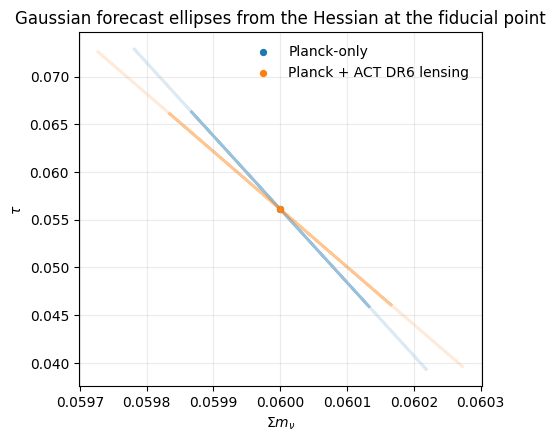

In [7]:
plot_parameter_ellipse(
    forecast_results,
    pair=CONTOUR_PAIR,
    fiducial=FIDUCIAL_COSMO,
    title='Gaussian forecast ellipses from the Hessian at the fiducial point',
)
